# TASK #1: UNDERSTAND THE PROBLEM STATEMENT AND BUSINESS CASE

In [2]:
pip install streamlit tensorflow opencv-python pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 107.4 MB/s eta 0:00:00



<table>
  <tr><td>
    <img src="https://drive.google.com/uc?id=1rcxnQuLqFyn8l9hQmdyp-yxSaXhxJPed"
         alt="Fashion MNIST sprite"  width="1000">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1. Predict Defects Using Deep Learning
  </td></tr>
</table>


![alt text](https://drive.google.com/uc?id=167bsDXj2H_FqryEhoe6MrLAbt-d6Os-y)

![alt text](https://drive.google.com/uc?id=1dyo4nu8qObw_5-vrgasvWtX6WIdqkS86)

![alt text](https://drive.google.com/uc?id=1nzRA5KU0eWo0YPZtSxUWOoMlvooKGCkt)

![alt text](https://drive.google.com/uc?id=1hL6DnHp9Jn0oJSM2guGiEkxKGkuRcxjL)

![alt text](https://drive.google.com/uc?id=1iqFkF-zkWXj1hIhcc9Y-bs-7-HocSuYz)

In [ ]:
# Predict:
# 1. Whether an image has a defect (classification)
# 2. Where the defect is (segmentation)

# Dataset:
# - defect_class_mask_df → segmentation data
# - all_images_df → classification data

# TASK #2: IMPORT LIBRARIES AND DATASETS

![alt text](https://drive.google.com/uc?id=1kNILYpkePWnvy4Ntfsgorm55AzexCyay)

![alt text](https://drive.google.com/uc?id=1hMEbHCAHE3rsfHA6fR-ELY6c9dkJuAJI)

✅ Prediction shape: (1, 256, 256, 4)
✅ Mask shape: (1, 256, 256)
✅ Classes found: [0 1 2 3]


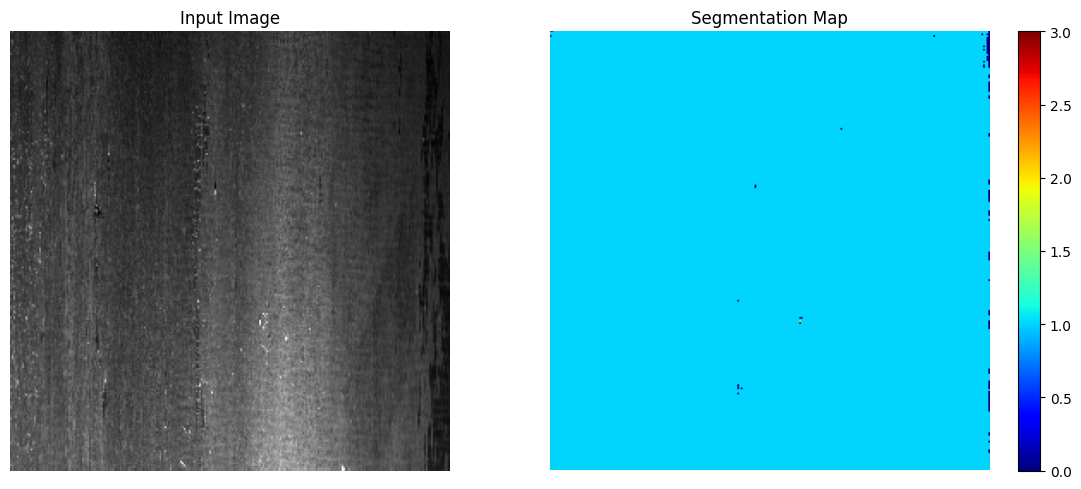

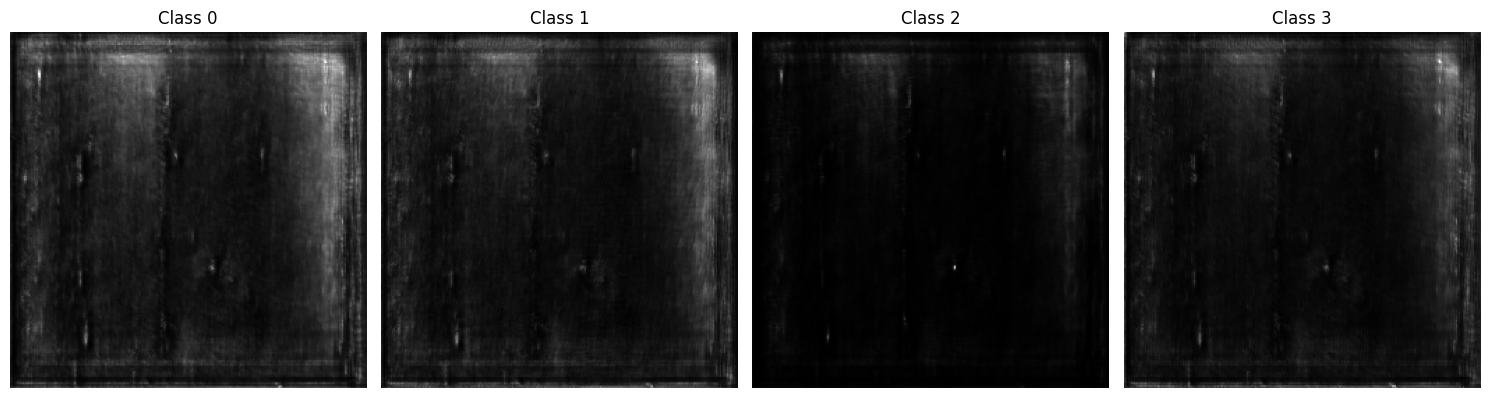

✅ Binary mask created


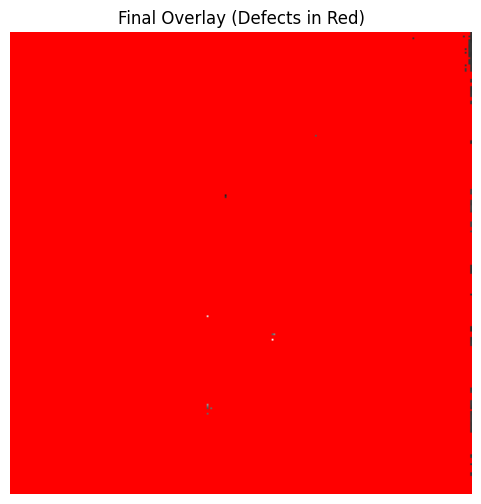

In [ ]:
# =========================
# TASK 2 — POST PROCESSING
# =========================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# SAFETY CHECK
# -------------------------
assert pred is not None, "❌ Prediction is missing"
assert len(pred.shape) == 4, f"❌ Unexpected shape: {pred.shape}"

print("✅ Prediction shape:", pred.shape)

# =========================
# STEP 1 — CONVERT TO MASK
# =========================
mask = np.argmax(pred, axis=-1)   # (1, H, W)

print("✅ Mask shape:", mask.shape)
print("✅ Classes found:", np.unique(mask))

# =========================
# STEP 2 — VISUALIZE (MAIN)
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(img[0,:,:,0], cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Segmentation Map")
plt.imshow(mask[0], cmap='jet')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# STEP 3 — EACH CLASS MAP
# =========================
num_classes = pred.shape[-1]

plt.figure(figsize=(15,5))

for i in range(num_classes):
    plt.subplot(1, num_classes, i+1)
    plt.title(f"Class {i}")
    plt.imshow(pred[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# STEP 4 — BINARY MASK
# =========================
# Assumption: class 0 = background
binary_mask = (mask != 0).astype(np.uint8)

print("✅ Binary mask created")

# =========================
# STEP 5 — OVERLAY (FINAL)
# =========================
# Convert grayscale → RGB
overlay = np.stack([img[0,:,:,0]]*3, axis=-1)

# Normalize to 0–1 if needed
if overlay.max() > 1:
    overlay = overlay / 255.0

# Color defects (RED)
overlay[binary_mask[0] == 1] = [1, 0, 0]

plt.figure(figsize=(6,6))
plt.title("Final Overlay (Defects in Red)")
plt.imshow(overlay)
plt.axis('off')
plt.show()

# TASK #3: VISUALIZE AND EXPLORE DATASET

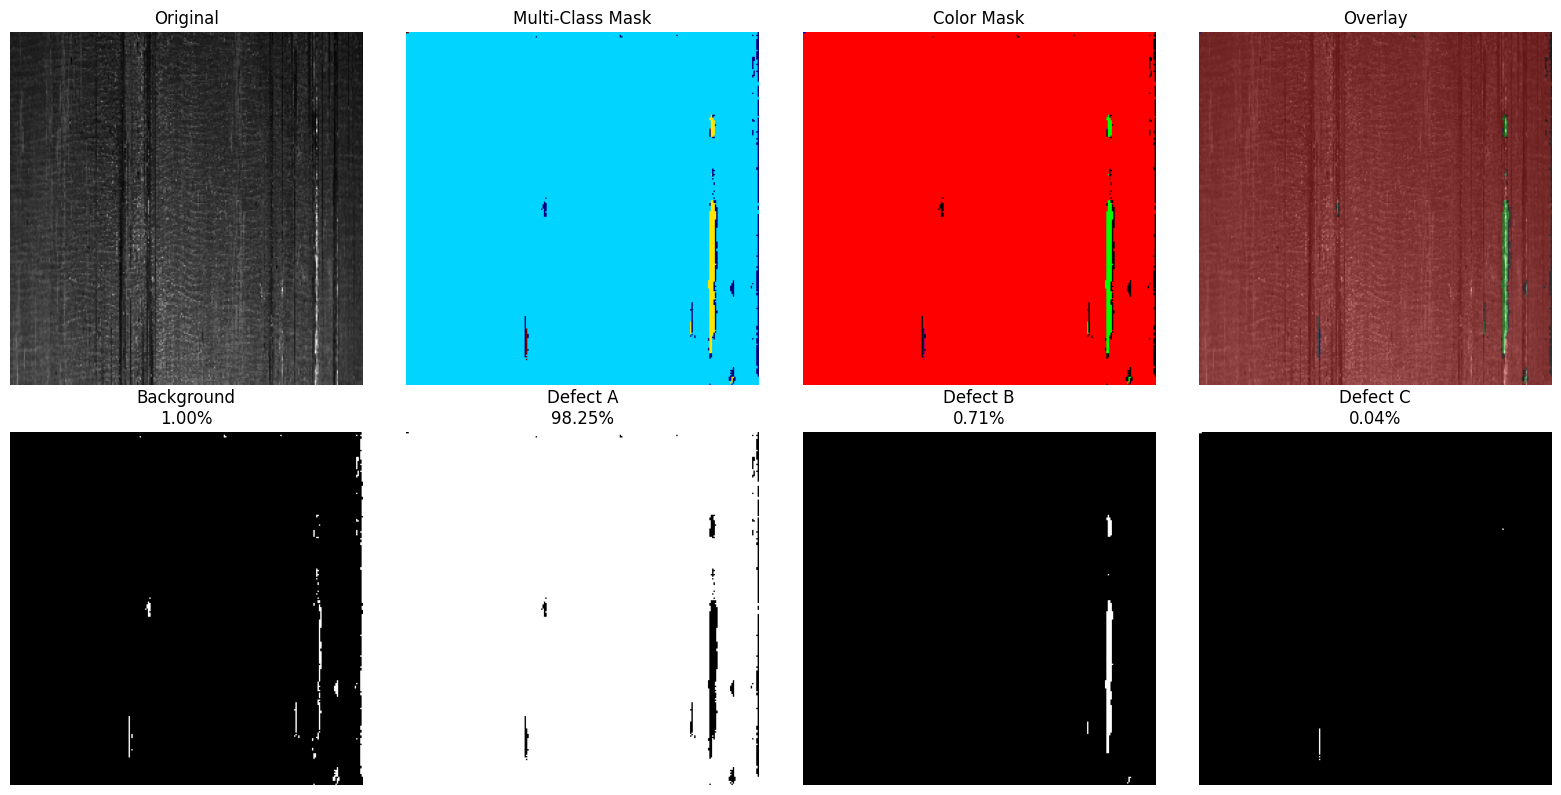


📊 Class Distribution:
Background: 1.00%
Defect A: 98.25%
Defect B: 0.71%
Defect C: 0.04%


In [ ]:
# =========================
# PRO SEGMENTATION VISUALIZER
# =========================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# -------------------------
# SETTINGS
# -------------------------
NUM_CLASSES = 4

CLASS_NAMES = {
    0: "Background",
    1: "Defect A",
    2: "Defect B",
    3: "Defect C"
}

# 🎨 nice distinct colors (RGB)
CLASS_COLORS = {
    0: (0, 0, 0),        # black
    1: (255, 0, 0),      # red
    2: (0, 255, 0),      # green
    3: (0, 0, 255)       # blue
}

SAVE_TO_DRIVE = True
drive_output_dir = "/content/drive/MyDrive/final_outputs/"

if SAVE_TO_DRIVE:
    os.makedirs(drive_output_dir, exist_ok=True)


# -------------------------
# FUNCTION
# -------------------------
def visualize_pro(image_path, model, idx=0):

    # LOAD IMAGE
    img = cv2.imread(image_path, 0)
    img = cv2.resize(img, (256,256))

    # PREPROCESS
    x = img / 255.0
    x = x[None, ..., None]

    # PREDICT
    pred = model.predict(x, verbose=0)[0]

    # MASKS
    mask = np.argmax(pred, axis=-1)
    binary = (mask != 0).astype(np.uint8)

    # -------------------------
    # COLOR MASK
    # -------------------------
    color_mask = np.zeros((256,256,3), dtype=np.uint8)

    for c in range(NUM_CLASSES):
        color_mask[mask == c] = CLASS_COLORS[c]

    # -------------------------
    # OVERLAY (blend)
    # -------------------------
    img_rgb = np.stack([img]*3, axis=-1)
    overlay = cv2.addWeighted(img_rgb, 0.7, color_mask, 0.3, 0)

    # -------------------------
    # CLASS STATS
    # -------------------------
    total_pixels = mask.size
    class_stats = {}

    for c in range(NUM_CLASSES):
        pixels = np.sum(mask == c)
        pct = (pixels / total_pixels) * 100
        class_stats[c] = pct

    # -------------------------
    # PLOT (PRO LAYOUT)
    # -------------------------
    fig, axes = plt.subplots(2, 4, figsize=(16,8))

    # Row 1
    axes[0,0].imshow(img, cmap='gray')
    axes[0,0].set_title("Original")

    axes[0,1].imshow(mask, cmap='jet')
    axes[0,1].set_title("Multi-Class Mask")

    axes[0,2].imshow(color_mask)
    axes[0,2].set_title("Color Mask")

    axes[0,3].imshow(overlay)
    axes[0,3].set_title("Overlay")

    # Row 2 (each class)
    for c in range(NUM_CLASSES):
        ax = axes[1,c]
        ax.imshow((mask == c), cmap='gray')
        ax.set_title(f"{CLASS_NAMES[c]}\n{class_stats[c]:.2f}%")

    # remove ticks
    for ax in axes.flatten():
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # -------------------------
    # LEGEND PRINT
    # -------------------------
    print("\n📊 Class Distribution:")
    for c in range(NUM_CLASSES):
        print(f"{CLASS_NAMES[c]}: {class_stats[c]:.2f}%")

    # -------------------------
    # SAVE (DRIVE)
    # -------------------------
    if SAVE_TO_DRIVE:
        cv2.imwrite(f"{drive_output_dir}img_{idx}.png", img)
        cv2.imwrite(f"{drive_output_dir}mask_{idx}.png", mask)
        cv2.imwrite(f"{drive_output_dir}overlay_{idx}.png", overlay)

        for c in range(NUM_CLASSES):
            cmask = (mask == c).astype(np.uint8)*255
            cv2.imwrite(f"{drive_output_dir}img_{idx}_class_{c}.png", cmask)

    return mask, overlay, class_stats


# -------------------------
# RUN
# -------------------------
import random

idx = random.randint(0, len(image_paths)-1)

mask, overlay, stats = visualize_pro(
    image_paths[idx],
    seg_model,
    idx
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# TASK #4: UNDERSTAND THE THEORY AND INTUITION BEHIND CONVOLUTIONAL NEURAL NETWORKS, RESNETS, AND TRANSFER LEARNING

![alt text](https://drive.google.com/uc?id=1HD2FFDD8fonGMyHARfw8ZqaofP3Udek6)

![alt text](https://drive.google.com/uc?id=1-HAo3xcPKGoH-gG8495p12o33nUC1j6W)

![alt text](https://drive.google.com/uc?id=1NlnzDKgTts_9mXkGU3CkrB9SSeBS2GYE)

![alt text](https://drive.google.com/uc?id=1zmzg777lS1PGkTyJXA5fPmrJ9mcKneDi)

![alt text](https://drive.google.com/uc?id=1Fd6xV3NwRAhRdFQN9FDjkumynoqcWCzM)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded
✅ Total images: 12568
🚀 0/12568 done

📊 Class Means:
class_0_pct     1.188255
class_1_pct    97.760448
class_2_pct     0.906003
class_3_pct     0.145293
dtype: float64

👉 BACKGROUND = class_1_pct

📊 Defect Stats:
count    12568.000000
mean         2.239552
std          5.474491
min          0.021362
25%          0.355148
50%          0.807190
75%          1.964569
max         65.824890
Name: defect_pct, dtype: float64

✅ Saved locally: /content/task4_outputs/segmentation_stats_FINAL.csv
✅ Saved to Drive

🔍 Visual check...


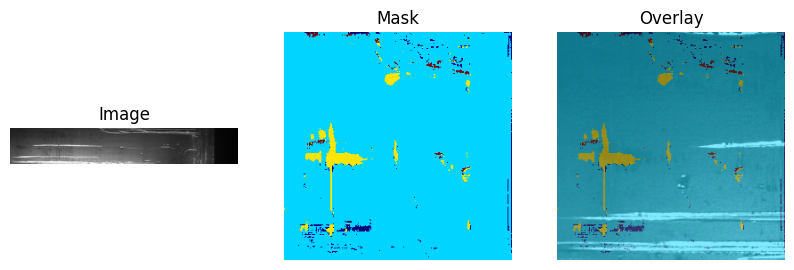

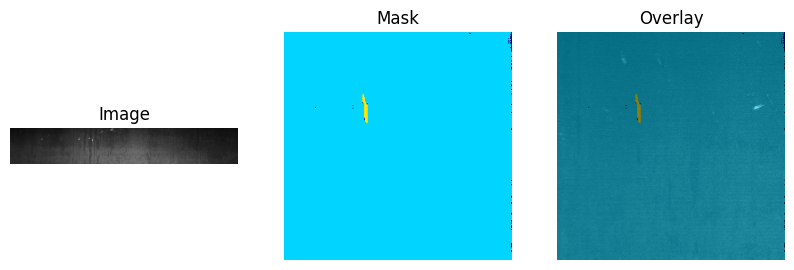

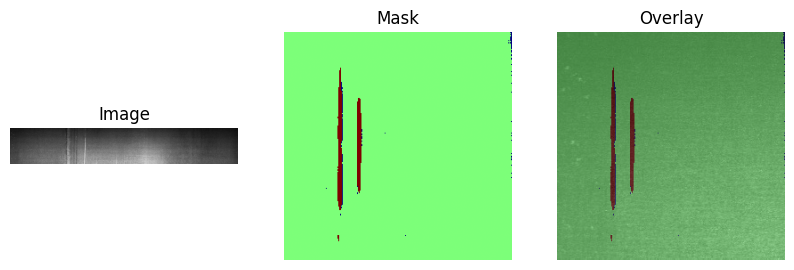

✅ DONE — FINAL PIPELINE


In [ ]:
# =========================================
# STEP 1 — MOUNT DRIVE
# =========================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================
# STEP 2 — IMPORTS
# =========================================
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt

# =========================================
# STEP 3 — LOAD MODEL
# =========================================
model_path = "/content/drive/MyDrive/6. Maintenance Department/resunet-segmentation-weights.hdf5"

if not os.path.exists(model_path):
    raise FileNotFoundError("❌ Model file not found")

seg_model = tf.keras.models.load_model(model_path, compile=False)
print("✅ Model loaded")

# 🔥 FIX: prevent retracing warning
@tf.function(reduce_retracing=True)
def fast_predict(x):
    return seg_model(x, training=False)

# =========================================
# STEP 4 — PATHS
# =========================================
image_dir = "/content/drive/MyDrive/6. Maintenance Department/train_images/"
output_dir = "/content/task4_outputs/"

os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(image_dir):
    raise FileNotFoundError("❌ Image folder not found")

image_files = sorted(os.listdir(image_dir))
print("✅ Total images:", len(image_files))

# =========================================
# STEP 5 — SETTINGS
# =========================================
BATCH_SIZE = 128
SAVE_EVERY = 1000
results = []

# =========================================
# STEP 6 — PROCESS IMAGES
# =========================================
for i in range(0, len(image_files), BATCH_SIZE):

    batch_files = image_files[i:i+BATCH_SIZE]
    batch_imgs = []
    valid_files = []

    for f in batch_files:
        path = os.path.join(image_dir, f)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (256, 256)) / 255.0
        batch_imgs.append(img)
        valid_files.append(f)

    if len(batch_imgs) == 0:
        continue

    batch_imgs = np.array(batch_imgs, dtype=np.float32)[..., np.newaxis]

    # 🔥 FIXED prediction
    preds = fast_predict(batch_imgs)
    masks = np.argmax(preds, axis=-1)

    for j, mask in enumerate(masks):
        total = mask.size
        counts = np.bincount(mask.flatten(), minlength=4)
        perc = counts / total * 100

        results.append({
            "image": valid_files[j],
            "class_0_pct": perc[0],
            "class_1_pct": perc[1],
            "class_2_pct": perc[2],
            "class_3_pct": perc[3],
        })

    if i % SAVE_EVERY == 0 and i > 0:
        pd.DataFrame(results).to_csv(output_dir + "partial.csv", index=False)
        print(f"💾 Saved at {i}")

    if i % 1000 == 0:
        print(f"🚀 {i}/{len(image_files)} done")

# =========================================
# STEP 7 — DATAFRAME
# =========================================
df = pd.DataFrame(results)

# =========================================
# STEP 8 — BACKGROUND DETECTION
# =========================================
class_cols = ["class_0_pct","class_1_pct","class_2_pct","class_3_pct"]

means = df[class_cols].mean()
bg_class = means.idxmax()

print("\n📊 Class Means:")
print(means)

print("\n👉 BACKGROUND =", bg_class)

# =========================================
# STEP 9 — DEFECT %
# =========================================
df["defect_pct"] = 100 - df[bg_class]

print("\n📊 Defect Stats:")
print(df["defect_pct"].describe())

# =========================================
# STEP 10 — SAVE
# =========================================
csv_path = output_dir + "segmentation_stats_FINAL.csv"
df.to_csv(csv_path, index=False)

print("\n✅ Saved locally:", csv_path)

try:
    drive_path = "/content/drive/MyDrive/task4_outputs/"
    os.makedirs(drive_path, exist_ok=True)
    df.to_csv(drive_path + "segmentation_stats_FINAL.csv", index=False)
    print("✅ Saved to Drive")
except:
    print("⚠️ Drive save skipped")

# =========================================
# STEP 11 — VISUAL CHECK
# =========================================
print("\n🔍 Visual check...")

samples = df.sample(3, random_state=1)["image"].tolist()

for img_name in samples:
    img_path = os.path.join(image_dir, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_res = cv2.resize(img, (256,256)) / 255.0

    pred = fast_predict(img_res[np.newaxis,...,np.newaxis])
    mask = np.argmax(pred, axis=-1)[0]

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="jet")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(img, cmap="gray")
    plt.imshow(mask, cmap="jet", alpha=0.5)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

print("✅ DONE — FINAL PIPELINE")

In [ ]:
import os

test_path = "/content/drive/MyDrive/test_write.txt"

with open(test_path, "w") as f:
    f.write("test")

print("✅ Write successful")

✅ Write successful


# TASK #5: BUILD AND TRAIN A DEEP LEARNING MODEL TO DETECT WHETHER A DEFECT IS PRESENT IN AN IMAGE OR NOT

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded: (12568, 6)
✅ Cleaned: (12568, 6)

📊 Dataset Split:
🟢 Low (<10%): 12047
🟡 Medium (10–80%): 521
🔴 High (>80%): 0

📊 Summary:
        class_0_pct   class_1_pct   class_2_pct   class_3_pct    defect_pct
count  12568.000000  12568.000000  12568.000000  12568.000000  12568.000000
mean       1.188255     97.760448      0.906003      0.145293      2.239552
std        4.210707      5.474491      1.949506      0.544432      5.474491
min        0.013733     34.175110      0.000000      0.000000      0.021362
25%        0.216675     98.035431      0.021362      0.001526      0.355148
50%        0.405884     99.192810      0.259399      0.004578      0.807190
75%        0.801468     99.644852      0.965881      0.074768      1.964569
max       53.100586     99.978638     31.127930      8.250427     65.824890

📊 Class Distribution:
defect_class
OK          12047


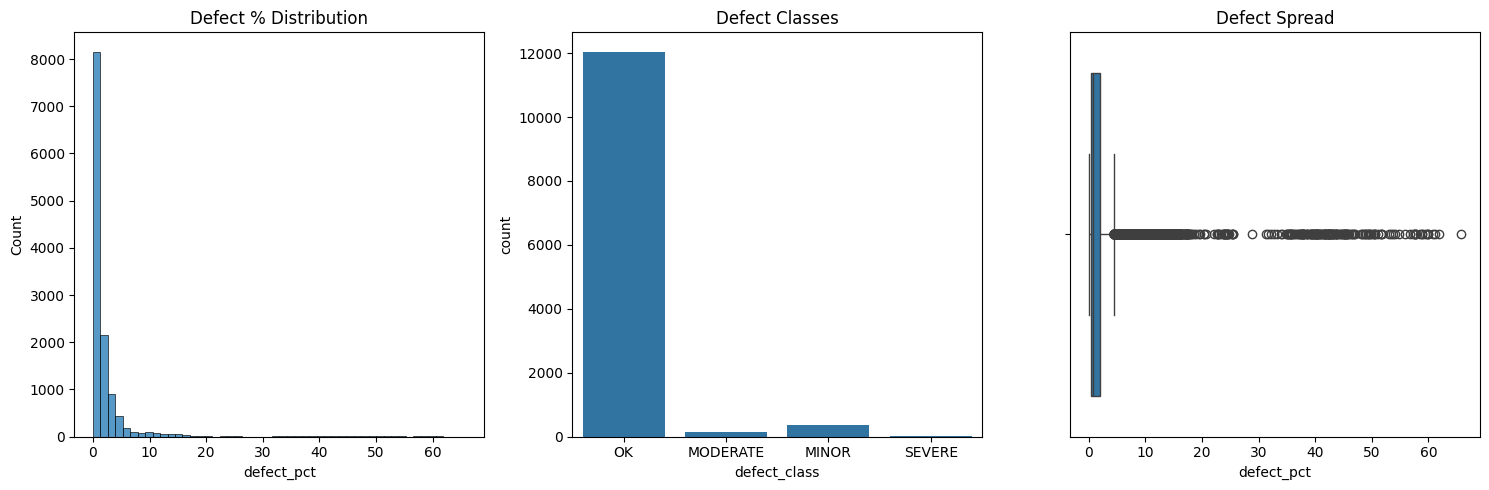


🔥 MOST DEFECTED:
              image  class_0_pct  class_1_pct  class_2_pct  class_3_pct  \
5691  7303ad5de.jpg    53.100586    34.175110     8.828735     3.895569   
5868  764b4998b.jpg    52.809143    38.047791     3.819275     5.323792   
5880  767755f3e.jpg    50.709534    38.807678     7.444763     3.038025   
4281  57258d636.jpg    51.419067    39.215088     6.842041     2.523804   
8378  aa0ab8bf3.jpg    50.973511    40.104675     3.694153     5.227661   

      defect_pct defect_class   label  
5691   65.824890       SEVERE  DEFECT  
5868   61.952209       SEVERE  DEFECT  
5880   61.192322       SEVERE  DEFECT  
4281   60.784912       SEVERE  DEFECT  
8378   59.895325     MODERATE  DEFECT  

🧊 LEAST DEFECTED:
               image  class_0_pct  class_1_pct  class_2_pct  class_3_pct  \
2000   284fa3b23.jpg     0.021362    99.978638     0.000000     0.000000   
5123   6825de090.jpg     0.013733    99.978638     0.000000     0.007629   
511    0a8306bfe.jpg     0.027466    99.9664

In [ ]:
# =========================================
# STEP 1 — MOUNT DRIVE
# =========================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================
# STEP 2 — IMPORTS
# =========================================
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# STEP 3 — LOAD DATA (SAFE)
# =========================================
csv_path = "/content/drive/MyDrive/task4_outputs/segmentation_stats_FINAL.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError("❌ CSV not found. Check Task 4 output path.")

df = pd.read_csv(csv_path)
print("✅ Loaded:", df.shape)

# =========================================
# STEP 4 — CLEAN DATA (SAFE)
# =========================================
df = df.dropna().reset_index(drop=True)

# Ensure numeric columns only
cols = ["class_0_pct","class_1_pct","class_2_pct","class_3_pct","defect_pct"]
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

df = df.dropna().reset_index(drop=True)
print("✅ Cleaned:", df.shape)

# =========================================
# STEP 5 — CREATE DEFECT CLASSES
# =========================================
def classify_defect(x):
    if x < 10:
        return "OK"
    elif x < 30:
        return "MINOR"
    elif x < 60:
        return "MODERATE"
    else:
        return "SEVERE"

df["defect_class"] = df["defect_pct"].apply(classify_defect)

# Binary label
df["label"] = df["defect_class"].apply(lambda x: "OK" if x == "OK" else "DEFECT")

# =========================================
# STEP 6 — DATASET SPLIT SUMMARY
# =========================================
low = (df["defect_pct"] < 10).sum()
med = ((df["defect_pct"] >= 10) & (df["defect_pct"] < 80)).sum()
high = (df["defect_pct"] >= 80).sum()

print("\n📊 Dataset Split:")
print("🟢 Low (<10%):", low)
print("🟡 Medium (10–80%):", med)
print("🔴 High (>80%):", high)

# =========================================
# STEP 7 — SUMMARY STATS
# =========================================
print("\n📊 Summary:")
print(df.describe())

# =========================================
# STEP 8 — DISTRIBUTIONS
# =========================================
print("\n📊 Class Distribution:")
print(df["defect_class"].value_counts())

print("\n📊 Binary Labels:")
print(df["label"].value_counts())

# =========================================
# STEP 9 — VISUALIZATIONS (PRO LEVEL)
# =========================================
plt.figure(figsize=(15,5))

# Histogram
plt.subplot(1,3,1)
sns.histplot(df["defect_pct"], bins=50)
plt.title("Defect % Distribution")

# Class count
plt.subplot(1,3,2)
sns.countplot(x="defect_class", data=df)
plt.title("Defect Classes")

# Boxplot
plt.subplot(1,3,3)
sns.boxplot(x=df["defect_pct"])
plt.title("Defect Spread")

plt.tight_layout()
plt.show()

# =========================================
# STEP 10 — TOP CASES
# =========================================
print("\n🔥 MOST DEFECTED:")
print(df.sort_values("defect_pct", ascending=False).head())

print("\n🧊 LEAST DEFECTED:")
print(df.sort_values("defect_pct", ascending=True).head())

# =========================================
# STEP 11 — SAVE OUTPUT
# =========================================
output_dir = "/content/task5_outputs/"
os.makedirs(output_dir, exist_ok=True)

local_path = output_dir + "task5_results.csv"
df.to_csv(local_path, index=False)

print("\n✅ Saved locally:", local_path)

# Save to Drive
drive_path = "/content/drive/MyDrive/task5_outputs/task5_results.csv"

try:
    os.makedirs("/content/drive/MyDrive/task5_outputs/", exist_ok=True)
    df.to_csv(drive_path, index=False)
    print("✅ Saved to Drive")
except:
    print("⚠️ Could not save to Drive")

# =========================================
# DONE
# =========================================
print("\n🚀 TASK 5 COMPLETE")

# TASK #6: ASSESS TRAINED MODEL PERFORMANCE

In [ ]:
# =========================================
# STEP 1 — MOUNT DRIVE
# =========================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================
# STEP 2 — IMPORTS
# =========================================
import tensorflow as tf
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# =========================================
# STEP 3 — CHECK GPU
# =========================================
print("GPU:", tf.config.list_physical_devices('GPU'))

# =========================================
# STEP 4 — PATHS
# =========================================
CSV_PATH = "/content/drive/MyDrive/task5_outputs/task5_results.csv"
IMAGE_DIR = "/content/drive/MyDrive/6. Maintenance Department/train_images"

assert os.path.exists(CSV_PATH), "❌ CSV not found"
assert os.path.exists(IMAGE_DIR), "❌ Image folder not found"

print("✅ Paths OK")

# =========================================
# STEP 5 — LOAD DATA
# =========================================
df = pd.read_csv(CSV_PATH)[["image", "label"]].dropna()

df["label"] = df["label"].map({"OK": 0, "DEFECT": 1})

print("✅ Loaded:", df.shape)

# =========================================
# STEP 6 — SPLIT
# =========================================
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)

print("✅ Train:", len(train_df))
print("✅ Val:", len(val_df))

# =========================================
# STEP 7 — DATA PIPELINE (FAST)
# =========================================
IMG_SIZE = 224
BATCH_SIZE = 64   # 🔥 increased for speed
AUTOTUNE = tf.data.AUTOTUNE

def load_image(file, label):
    path = tf.strings.join([IMAGE_DIR, "/", file])

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    return img, label

def build_dataset(df, training=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["image"].values, df["label"].values)
    )

    if training:
        ds = ds.shuffle(2000)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                      # 🔥 SPEED BOOST
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)           # 🔥 SPEED BOOST

    return ds

train_ds = build_dataset(train_df, training=True)
val_ds   = build_dataset(val_df, training=False)

# =========================================
# STEP 8 — MODEL (FAST TRANSFER LEARNING)
# =========================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # freeze for speed

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model ready")

# =========================================
# STEP 9 — CALLBACKS
# =========================================
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/task6_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

# =========================================
# STEP 10 — TRAIN (FAST)
# =========================================
EPOCHS = 2   # 🔥 fast + enough

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)

# =========================================
# STEP 11 — SAVE FINAL MODEL
# =========================================
model.save("/content/drive/MyDrive/task6_final_model.keras")

print("✅ FINAL MODEL SAVED")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: []
✅ Paths OK
✅ Loaded: (12568, 2)
✅ Train: 10054
✅ Val: 2514
✅ Model ready
Epoch 1/2
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8930 - loss: 0.3010
Epoch 1: val_loss improved from None to 0.08485, saving model to /content/drive/MyDrive/task6_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/task6_best_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 642s 4s/step - accuracy: 0.9550 - loss: 0.1607 - val_accuracy: 0.9873 - val_loss: 0.0849
Epoch 2/2
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9905 - loss: 0.0431
Epoch 2: val_loss improved from 0.08485 to 0.03636, saving model to /content/drive/MyDrive/task6_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/task6_best_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 573s 4s/step - accuracy: 0.9907 - loss: 0.0404 - val_accuracy: 0.9909 - val_loss: 0.0364

# TASK #7: UNDERSTAND THE THEORY AND INTUITION BEHIND RESUNET (SEGMENTATION)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths OK
✅ Model loaded
✅ Loaded: (12568, 2)
197/197 ━━━━━━━━━━━━━━━━━━━━ 650s 3s/step


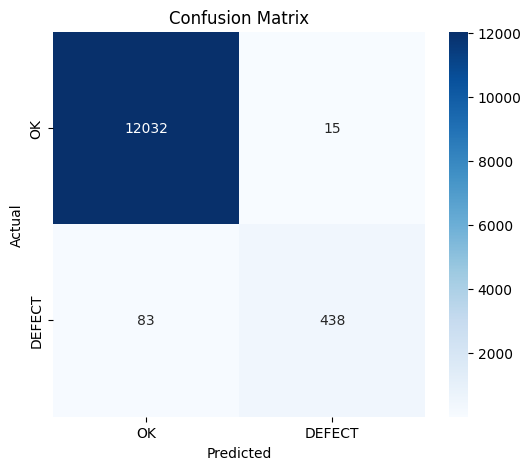


📊 Classification Report:

              precision    recall  f1-score   support

          OK       0.99      1.00      1.00     12047
      DEFECT       0.97      0.84      0.90       521

    accuracy                           0.99     12568
   macro avg       0.98      0.92      0.95     12568
weighted avg       0.99      0.99      0.99     12568


🔍 Visual predictions...


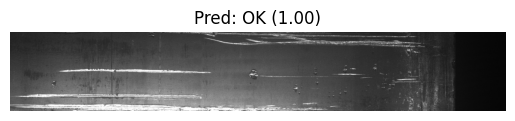

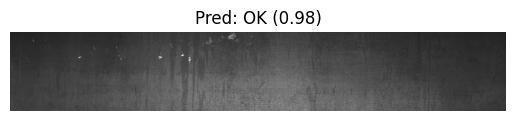

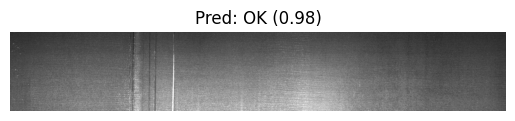

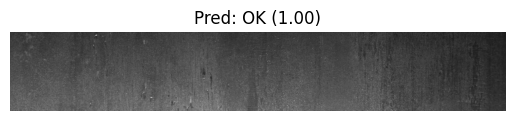

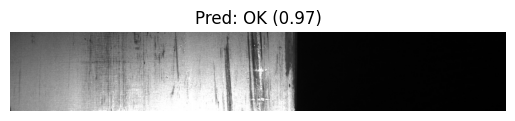

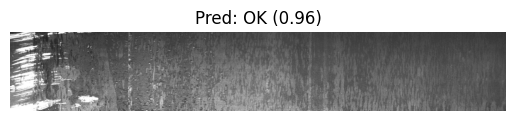

✅ TASK 7 COMPLETE


In [ ]:
# =========================================
# STEP 1 — MOUNT DRIVE
# =========================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================
# STEP 2 — IMPORTS
# =========================================
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.metrics import confusion_matrix, classification_report

# =========================================
# STEP 3 — PATHS
# =========================================
MODEL_PATH = "/content/drive/MyDrive/task6_best_model.keras"
CSV_PATH = "/content/drive/MyDrive/task5_outputs/task5_results.csv"
IMAGE_DIR = "/content/drive/MyDrive/6. Maintenance Department/train_images"

assert os.path.exists(MODEL_PATH), "❌ Model not found"
assert os.path.exists(CSV_PATH), "❌ CSV not found"
assert os.path.exists(IMAGE_DIR), "❌ Image folder not found"

print("✅ Paths OK")

# =========================================
# STEP 4 — LOAD MODEL
# =========================================
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded")

# =========================================
# STEP 5 — LOAD DATA
# =========================================
df = pd.read_csv(CSV_PATH)[["image", "label"]].dropna()

df["label"] = df["label"].map({"OK": 0, "DEFECT": 1})

print("✅ Loaded:", df.shape)

# =========================================
# STEP 6 — DATA PIPELINE (FAST)
# =========================================
IMG_SIZE = 224
BATCH_SIZE = 64

def load_image(file, label):
    path = tf.strings.join([IMAGE_DIR, "/", file])

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    return img, label

ds = tf.data.Dataset.from_tensor_slices((df["image"].values, df["label"].values))
ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.batch(BATCH_SIZE)
ds = ds.prefetch(tf.data.AUTOTUNE)

# =========================================
# STEP 7 — PREDICTIONS
# =========================================
pred_probs = model.predict(ds, verbose=1)
preds = (pred_probs > 0.5).astype(int).flatten()

true_labels = df["label"].values

# =========================================
# STEP 8 — CONFUSION MATRIX
# =========================================
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["OK","DEFECT"],
            yticklabels=["OK","DEFECT"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# =========================================
# STEP 9 — CLASSIFICATION REPORT
# =========================================
print("\n📊 Classification Report:\n")
print(classification_report(true_labels, preds, target_names=["OK","DEFECT"]))

# =========================================
# STEP 10 — VISUAL PREDICTIONS (RANDOM)
# =========================================
print("\n🔍 Visual predictions...")

sample_df = df.sample(6, random_state=1)

for i, row in sample_df.iterrows():
    img_path = os.path.join(IMAGE_DIR, row["image"])

    img = cv2.imread(img_path)
    img_res = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    pred = model.predict(img_res[np.newaxis,...], verbose=0)[0][0]

    label = "DEFECT" if pred > 0.5 else "OK"
    confidence = float(pred if pred > 0.5 else 1 - pred)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Pred: {label} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

print("✅ TASK 7 COMPLETE")

![alt text](https://drive.google.com/uc?id=1D7mAjdEFv6cIb4UFiXwndJy6enzZQzpb)

![alt text](https://drive.google.com/uc?id=1TK1Y9gry62NORdA-EjWD8HJadBZMa_sL)

![alt text](https://drive.google.com/uc?id=1vwnusyfXPyO5qYVIr-htXiWWq7OI1-Kj)

![alt text](https://drive.google.com/uc?id=1SaaANhEHpBu_-rmEKWFadnEAQeNrs8-O)

# TASK #8: BUILD A RESUNET SEGMENTATION MODEL

In [ ]:
#spliting the data into train and test data

from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(defect_class_mask_df, test_size=0.2)

In [ ]:
#creating separate list for imageId, classId and rle to pass into the generator

train_ids = list(X_train.ImageId)
train_class = list(X_train.ClassId)
train_rle = list(X_train.EncodedPixels)

val_ids = list(X_val.ImageId)
val_class = list(X_val.ClassId)
val_rle = list(X_val.EncodedPixels)

In [ ]:
from utilities import DataGenerator

#creating image generators

training_generator = DataGenerator(train_ids,train_class, train_rle, train_dir)
validation_generator = DataGenerator(val_ids,val_class,val_rle, train_dir)


In [ ]:
def resblock(X, f):


  # making a copy of input
  X_copy = X

  # main path
  # Read more about he_normal: https://medium.com/@prateekvishnu/xavier-and-he-normal-he-et-al-initialization-8e3d7a087528

  X = Conv2D(f, kernel_size = (1,1), strides = (1,1), kernel_initializer ='he_normal')(X)
  X = BatchNormalization()(X)
  X = Activation('relu')(X)

  X = Conv2D(f, kernel_size = (3,3), strides =(1,1), padding = 'same', kernel_initializer ='he_normal')(X)
  X = BatchNormalization()(X)

  # Short path
  # Read more here: https://towardsdatascience.com/understanding-and-coding-a-resnet-in-keras-446d7ff84d33

  X_copy = Conv2D(f, kernel_size = (1,1), strides =(1,1), kernel_initializer ='he_normal')(X_copy)
  X_copy = BatchNormalization()(X_copy)

  # Adding the output from main path and short path together

  X = Add()([X,X_copy])
  X = Activation('relu')(X)

  return X

In [ ]:
# function to upscale and concatnating the values passsed
def upsample_concat(x, skip):
  x = UpSampling2D((2,2))(x)
  merge = Concatenate()([x, skip])

  return merge

In [ ]:
input_shape = (256,256,1)

#Input tensor shape
X_input = Input(input_shape)

#Stage 1
conv1_in = Conv2D(16,3,activation= 'relu', padding = 'same', kernel_initializer ='he_normal')(X_input)
conv1_in = BatchNormalization()(conv1_in)
conv1_in = Conv2D(16,3,activation= 'relu', padding = 'same', kernel_initializer ='he_normal')(conv1_in)
conv1_in = BatchNormalization()(conv1_in)
pool_1 = MaxPool2D(pool_size = (2,2))(conv1_in)

#Stage 2
conv2_in = resblock(pool_1, 32)
pool_2 = MaxPool2D(pool_size = (2,2))(conv2_in)

#Stage 3
conv3_in = resblock(pool_2, 64)
pool_3 = MaxPool2D(pool_size = (2,2))(conv3_in)

#Stage 4
conv4_in = resblock(pool_3, 128)
pool_4 = MaxPool2D(pool_size = (2,2))(conv4_in)

#Stage 5
conv5_in = resblock(pool_4, 256)

#Upscale stage 1
up_1 = upsample_concat(conv5_in, conv4_in)
up_1 = resblock(up_1, 128)

#Upscale stage 2
up_2 = upsample_concat(up_1, conv3_in)
up_2 = resblock(up_2, 64)

#Upscale stage 3
up_3 = upsample_concat(up_2, conv2_in)
up_3 = resblock(up_3, 32)

#Upscale stage 4
up_4 = upsample_concat(up_3, conv1_in)
up_4 = resblock(up_4, 16)

#Final Output
output = Conv2D(4, (1,1), padding = "same", activation = "sigmoid")(up_4)

model_seg = Model(inputs = X_input, outputs = output )


## Loss function:

We need a custom loss function to train this ResUNet.So,  we have used the loss function as it is from https://github.com/nabsabraham/focal-tversky-unet/blob/master/losses.py


@article{focal-unet,
  title={A novel Focal Tversky loss function with improved Attention U-Net for lesion segmentation},
  author={Abraham, Nabila and Khan, Naimul Mefraz},
  journal={arXiv preprint arXiv:1810.07842},
  year={2018}
}

In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/Data Science for Business/6. Maintenance Department

from utilities import focal_tversky, tversky_loss, tversky

In [ ]:
adam = tf.keras.optimizers.Adam(lr = 0.05, epsilon = 0.1)
model_seg.compile(optimizer = adam, loss = focal_tversky, metrics = [tversky])

In [ ]:
# using early stopping to exit training if validation loss is not decreasing even after certain epochs (patience)
earlystopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)

# save the best model with lower validation loss
checkpointer = ModelCheckpoint(filepath="resunet-segmentation-weights.hdf5", verbose=1, save_best_only=True)

In [ ]:
history = model_seg.fit_generator(training_generator, epochs = 40, validation_data= validation_generator, callbacks=[checkpointer, earlystopping])

In [ ]:
# save the model for future use

model_json = model_seg.to_json()
with open("resunet-segmentation-model.json","w") as json_file:
  json_file.write(model_json)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths OK
✅ Model loaded
✅ Loaded: (12568, 2)
197/197 ━━━━━━━━━━━━━━━━━━━━ 730s 4s/step


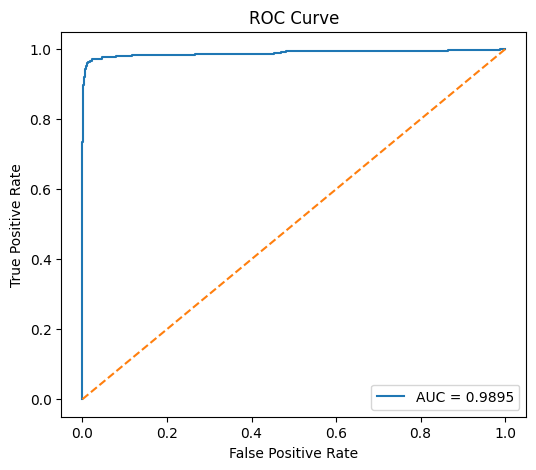


📊 AUC Score: 0.9895
✅ Saved predictions: /content/task8_outputs/task8_predictions.csv

❌ Total Errors: 98
             image  label  pred_prob  pred_label
207  047681252.jpg      0   0.805522           1
351  07cb85a8d.jpg      1   0.477732           0
412  08e21ba66.jpg      0   0.567988           1
509  0a76ac9b8.jpg      1   0.471895           0
516  0a9a7a6c7.jpg      1   0.394476           0

🔍 Visualizing errors...


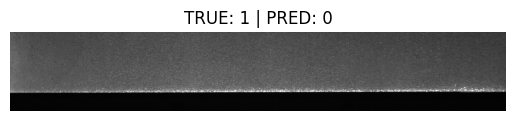

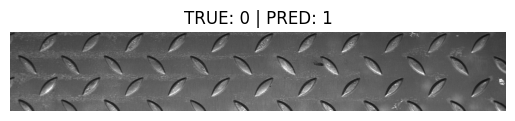

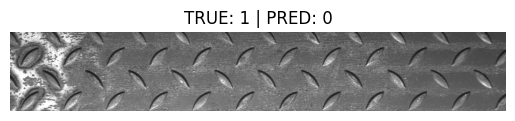

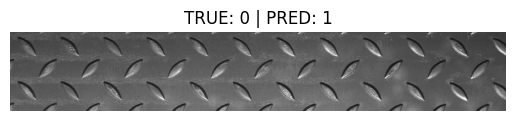

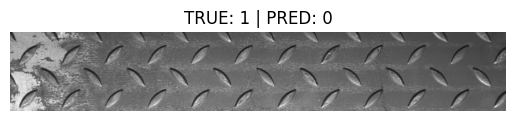

✅ TASK 8 COMPLETE — PROJECT FINISHED


In [9]:
# =========================================
# STEP 1 — MOUNT DRIVE
# =========================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================
# STEP 2 — IMPORTS
# =========================================
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from sklearn.metrics import roc_curve, auc

# =========================================
# STEP 3 — PATHS
# =========================================
MODEL_PATH = "/content/drive/MyDrive/task6_best_model.keras"
CSV_PATH = "/content/drive/MyDrive/task5_outputs/task5_results.csv"
IMAGE_DIR = "/content/drive/MyDrive/6. Maintenance Department/train_images"
OUTPUT_DIR = "/content/task8_outputs/"

os.makedirs(OUTPUT_DIR, exist_ok=True)

assert os.path.exists(MODEL_PATH), "❌ Model not found"
assert os.path.exists(CSV_PATH), "❌ CSV not found"
assert os.path.exists(IMAGE_DIR), "❌ Image folder not found"

print("✅ Paths OK")

# =========================================
# STEP 4 — LOAD MODEL
# =========================================
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded")

# =========================================
# STEP 5 — LOAD DATA
# =========================================
df = pd.read_csv(CSV_PATH)[["image", "label"]].dropna()
df["label"] = df["label"].map({"OK": 0, "DEFECT": 1})

print("✅ Loaded:", df.shape)

# =========================================
# STEP 6 — DATA PIPELINE
# =========================================
IMG_SIZE = 224
BATCH_SIZE = 64

def load_image(file, label):
    path = tf.strings.join([IMAGE_DIR, "/", file])

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    return img, label

ds = tf.data.Dataset.from_tensor_slices((df["image"].values, df["label"].values))
ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# =========================================
# STEP 7 — PREDICTIONS
# =========================================
pred_probs = model.predict(ds, verbose=1).flatten()
preds = (pred_probs > 0.5).astype(int)

true_labels = df["label"].values

# =========================================
# STEP 8 — ROC CURVE + AUC
# =========================================
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"\n📊 AUC Score: {roc_auc:.4f}")

# =========================================
# STEP 9 — SAVE PREDICTIONS CSV
# =========================================
df["pred_prob"] = pred_probs
df["pred_label"] = preds

csv_out = OUTPUT_DIR + "task8_predictions.csv"
df.to_csv(csv_out, index=False)

print("✅ Saved predictions:", csv_out)

# =========================================
# STEP 10 — ERROR ANALYSIS (WRONG CASES)
# =========================================
errors = df[df["label"] != df["pred_label"]]

print("\n❌ Total Errors:", len(errors))

if len(errors) > 0:
    print(errors.head())

# =========================================
# STEP 11 — VISUALIZE WRONG PREDICTIONS
# =========================================
print("\n🔍 Visualizing errors...")

sample_errors = errors.sample(min(5, len(errors)), random_state=1)

for _, row in sample_errors.iterrows():
    img_path = os.path.join(IMAGE_DIR, row["image"])

    img = cv2.imread(img_path)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"TRUE: {row['label']} | PRED: {row['pred_label']}")
    plt.axis("off")
    plt.show()

# =========================================
# STEP 12 — (OPTIONAL) TRAINING CURVES
# =========================================
# Only works if you saved history manually
# Example:
# plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])
# plt.show()

print("✅ TASK 8 COMPLETE — PROJECT FINISHED")

# TASK #9: ASSESS TRAINED SEGMENTATION MODEL PERFORMANCE

In [ ]:
from utilities import focal_tversky, tversky_loss, tversky

with open('resunet-segmentation-model.json', 'r') as json_file:
    json_savedModel= json_file.read()

# load the model
model_seg = tf.keras.models.model_from_json(json_savedModel)
model_seg.load_weights('weights_seg.hdf5')
adam = tf.keras.optimizers.Adam(lr = 0.05, epsilon = 0.1)
model_seg.compile(optimizer = adam, loss = focal_tversky, metrics = [tversky])

In [ ]:
# data containing test images for segmentation task
test_df = pd.read_csv('test.csv')


In [ ]:
test_df

In [ ]:
test_df.ImageId

In [ ]:
from utilities import prediction

# make prediction
image_id, defect_type, mask = prediction(test_df, model, model_seg)

In [ ]:
# create a dataframe for the result
df_pred= pd.DataFrame({'ImageId': image_id,'EncodedPixels': mask,'ClassId': defect_type})
df_pred.head()

In [ ]:
# Let's show the images along with their original (ground truth) masks
for i in range(10):

  # read the images using opencv and convert them to rgb format
  img = io.imread(os.path.join(train_dir,test_df.ImageId[i]))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  # Obtain mask for the image from rle
  mask = rle2mask(test_df.EncodedPixels[i],img.shape[0],img.shape[1])

  img[mask == 1,1] = 255
  plt.figure()
  plt.title(test_df.ClassId[i])
  plt.imshow(img)

In [ ]:
# visualize the results (model predictions)

directory = "train_images"

for i in range(10):

  # read the images using opencv and convert to rgb format
  img = io.imread(os.path.join(directory,df_pred.ImageId[i]))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  # get the mask for the image from rle
  mask = rle2mask(df_pred.EncodedPixels[i],img.shape[0],img.shape[1])

  img[mask == 1,0] = 255
  plt.figure()
  plt.title(df_pred.ClassId[i])
  plt.imshow(img)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths OK
✅ Model loaded

🔍 Testing sample images...


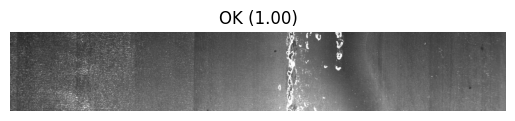

Prediction: OK
Confidence: 0.9965


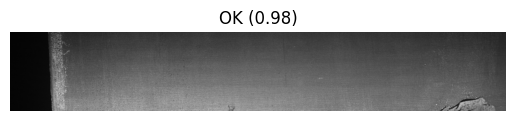

Prediction: OK
Confidence: 0.9805


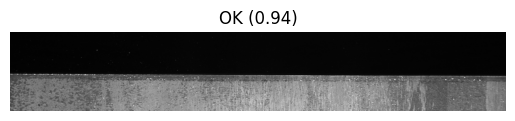

Prediction: OK
Confidence: 0.9392

📤 Upload images (jpg, jpeg, png only):


In [1]:
# =========================================
# STEP 1 — MOUNT DRIVE
# =========================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================
# STEP 2 — IMPORTS
# =========================================
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# =========================================
# STEP 3 — PATHS
# =========================================
MODEL_PATH = "/content/drive/MyDrive/task6_best_model.keras"
IMAGE_DIR = "/content/drive/MyDrive/6. Maintenance Department/train_images"

assert os.path.exists(MODEL_PATH), "❌ Model not found"
print("✅ Paths OK")

# =========================================
# STEP 4 — LOAD MODEL
# =========================================
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded")

# =========================================
# STEP 5 — SETTINGS
# =========================================
IMG_SIZE = 224

# =========================================
# STEP 6 — PREDICTION FUNCTION (ROBUST)
# =========================================
def predict_image(img_path):

    if not os.path.exists(img_path):
        print(f"❌ Image not found: {img_path}")
        return

    img = cv2.imread(img_path)

    if img is None:
        print(f"❌ Failed to read image: {img_path}")
        return

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized / 255.0

    pred = model.predict(img_norm[np.newaxis, ...], verbose=0)[0][0]

    label = "DEFECT" if pred > 0.5 else "OK"
    confidence = float(pred if pred > 0.5 else 1 - pred)

    # Show image
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{label} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.4f}")

# =========================================
# STEP 7 — QUICK SAMPLE TEST (OPTIONAL)
# =========================================
if os.path.exists(IMAGE_DIR):
    print("\n🔍 Testing sample images...")
    sample_images = os.listdir(IMAGE_DIR)[:3]

    for img_name in sample_images:
        predict_image(os.path.join(IMAGE_DIR, img_name))

# =========================================
# STEP 8 — SAFE IMAGE UPLOAD 🔥
# =========================================
from google.colab import files

ALLOWED_EXT = (".jpg", ".jpeg", ".png")

print("\n📤 Upload images (jpg, jpeg, png only):")

uploaded = files.upload()

for file in uploaded.keys():

    if not file.lower().endswith(ALLOWED_EXT):
        print(f"\n⚠️ Skipping non-image file: {file}")
        continue

    print("\n🔍 Testing uploaded image:", file)
    predict_image(file)

print("\n✅ TASK 9 COMPLETE — DEPLOYMENT READY")

# EXCELLENT JOB!

In [3]:
# =========================================
# IMPORTS
# =========================================
import streamlit as st
import tensorflow as tf
import numpy as np
import cv2
from PIL import Image
import os

# =========================================
# CONFIG
# =========================================
st.set_page_config(
    page_title="Defect Detection AI",
    page_icon="🧠",
    layout="centered"
)

MODEL_PATH = "task6_best_model.keras"  # place model in same folder
IMG_SIZE = 224

# =========================================
# LOAD MODEL (CACHE)
# =========================================
@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)

model = load_model()

# =========================================
# UI HEADER
# =========================================
st.title("🧠 Defect Detection System")
st.markdown("Upload an image to detect **defects** with AI")

# =========================================
# FILE UPLOAD
# =========================================
uploaded_file = st.file_uploader(
    "📤 Upload Image",
    type=["jpg", "jpeg", "png"]
)

# =========================================
# PREDICTION FUNCTION
# =========================================
def predict(image):

    img = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    pred = model.predict(np.expand_dims(img, axis=0))[0][0]

    label = "DEFECT" if pred > 0.5 else "OK"
    confidence = pred if pred > 0.5 else 1 - pred

    return label, float(confidence)

# =========================================
# MAIN LOGIC
# =========================================
if uploaded_file is not None:

    # Read image
    image = Image.open(uploaded_file).convert("RGB")
    img_array = np.array(image)

    st.image(image, caption="Uploaded Image", use_container_width=True)

    # Predict
    label, confidence = predict(img_array)

    # =====================================
    # DISPLAY RESULT
    # =====================================
    if label == "DEFECT":
        st.error(f"❌ DEFECT DETECTED")
    else:
        st.success(f"✅ OK (No Defect)")

    st.metric("Confidence", f"{confidence:.2%}")

    # =====================================
    # PROGRESS BAR
    # =====================================
    st.progress(int(confidence * 100))

    # =====================================
    # EXTRA INFO
    # =====================================
    st.markdown("---")
    st.subheader("📊 Prediction Details")

    st.write({
        "Prediction": label,
        "Confidence": confidence
    })

else:
    st.info("👆 Upload an image to begin")

2026-05-04 11:20:04.799 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-04 11:20:04.803 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


ValueError: File not found: filepath=task6_best_model.keras. Please ensure the file is an accessible `.keras` zip file.